Holiday Package Prediction

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

In [2]:
df = pd.read_csv("Travel.csv")

In [3]:
df.head()

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


Data Cleaning 

In [4]:
df.isnull().sum()

CustomerID                    0
ProdTaken                     0
Age                         226
TypeofContact                25
CityTier                      0
DurationOfPitch             251
Occupation                    0
Gender                        0
NumberOfPersonVisiting        0
NumberOfFollowups            45
ProductPitched                0
PreferredPropertyStar        26
MaritalStatus                 0
NumberOfTrips               140
Passport                      0
PitchSatisfactionScore        0
OwnCar                        0
NumberOfChildrenVisiting     66
Designation                   0
MonthlyIncome               233
dtype: int64

In [5]:
df['Gender'].value_counts()

Gender
Male       2916
Female     1817
Fe Male     155
Name: count, dtype: int64

In [6]:
df['MaritalStatus'].value_counts()

MaritalStatus
Married      2340
Divorced      950
Single        916
Unmarried     682
Name: count, dtype: int64

In [7]:
df['TypeofContact'].value_counts()

TypeofContact
Self Enquiry       3444
Company Invited    1419
Name: count, dtype: int64

In [8]:
df['Gender']=df['Gender'].replace('Fe male','Female')
df['MaritalStatus']=df['MaritalStatus'].replace('Unmar ried','Unmarried')

In [9]:
df.head()

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


In [10]:
##checking missing values
features_with_na = [features for features in df.columns if df[features].isnull().sum() >=1]
for feature in features_with_na:
    print(feature, np.round(df[feature].isnull().mean()*100,5), '%missing values')

Age 4.62357 %missing values
TypeofContact 0.51146 %missing values
DurationOfPitch 5.13502 %missing values
NumberOfFollowups 0.92062 %missing values
PreferredPropertyStar 0.53191 %missing values
NumberOfTrips 2.86416 %missing values
NumberOfChildrenVisiting 1.35025 %missing values
MonthlyIncome 4.76678 %missing values


In [11]:
## statistics of numerical features
df[features_with_na].select_dtypes(exclude='object').describe()

,Age,DurationOfPitch,NumberOfFollowups,PreferredPropertyStar,NumberOfTrips,NumberOfChildrenVisiting,MonthlyIncome
count,4662.000000,4637.000000,4843.000000,4862.000000,4748.000000,4822.000000,4655.000000
mean,37.622265,15.490835,3.708445,3.581037,3.236521,1.187267,23619.853491
std,9.316387,8.519643,1.002509,0.798009,1.849019,0.857861,5380.698361
min,18.000000,5.000000,1.000000,3.000000,1.000000,0.000000,1000.000000
25%,31.000000,9.000000,3.000000,3.000000,2.000000,1.000000,20346.000000
50%,36.000000,13.000000,4.000000,3.000000,3.000000,1.000000,22347.000000
75%,44.000000,20.000000,4.000000,4.000000,4.000000,2.000000,25571.000000
max,61.000000,127.000000,6.000000,5.000000,22.000000,3.000000,98678.000000


In [12]:
# Numerical columns → median
num_cols = ['Age', 'NumberOfFollowups', 'NumberOfTrips', 'MonthlyIncome', 'DurationOfPitch']

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Categorical columns → mode
cat_cols = ['TypeofContact', 'PreferredPropertyStar', 'NumberOfChildrenVisiting']

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [13]:
df.head()

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,36.0,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


In [14]:
df.isnull().sum()

CustomerID                  0
ProdTaken                   0
Age                         0
TypeofContact               0
CityTier                    0
DurationOfPitch             0
Occupation                  0
Gender                      0
NumberOfPersonVisiting      0
NumberOfFollowups           0
ProductPitched              0
PreferredPropertyStar       0
MaritalStatus               0
NumberOfTrips               0
Passport                    0
PitchSatisfactionScore      0
OwnCar                      0
NumberOfChildrenVisiting    0
Designation                 0
MonthlyIncome               0
dtype: int64

In [15]:
df.drop('CustomerID',inplace=True, axis=1)

## Feature Engineering

In [16]:
# create new column for feature 
df['TotalVisiting']=df['NumberOfPersonVisiting']+df['NumberOfChildrenVisiting']
df.drop(columns=['NumberOfPersonVisiting','NumberOfChildrenVisiting'], inplace=True)

In [17]:
## get all the numerical features
num_features = [feature for feature in df.columns if df[feature].dtype != 'O']
print('Num of numerical features: ', len(num_features))

Num of numerical features:  18


In [18]:
##Categorical features
cat_features = [feature for feature in df.columns if df[feature].dtype == 'O']
print('Num of categorical features: ', len(cat_features))

Num of categorical features:  0


In [19]:
## discrete features
discrete_features = [feature for feature in num_features if len(df[feature].unique())<25]
print('No. of Discrete features: ', len(discrete_features))

No. of Discrete features:  15


In [20]:
## continuous features
continuous_features = [feature for feature in num_features if feature not in discrete_features]
print('No. of Continuous features: ', len(continuous_features))

No. of Continuous features:  3


In [21]:
# convert numeric columns properly
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')
# fix string dtype
for col in df.columns:
    if df[col].dtype.name == 'string':
        df[col] = df[col].astype('object')

## train test split and model training


In [22]:
X = df.drop(['ProdTaken'], axis=1)
y = df['ProdTaken']

In [23]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [24]:
num_features = x_train.select_dtypes(include=['int64','float64']).columns
cat_features = x_train.select_dtypes(include=['object']).columns

In [25]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
])

In [26]:
x_train = preprocessor.fit_transform(x_train)
x_test = preprocessor.transform(x_test)

In [27]:
x_train

array([[-0.15792615,         nan, -0.7214003 , ...,         nan,
        -0.38224537, -0.77415132],
       [ 0.50807196,         nan, -0.7214003 , ...,         nan,
        -0.4597992 ,  0.64361526],
       [ 1.39606944,         nan, -0.7214003 , ...,         nan,
        -0.24519557, -0.06526803],
       ...,
       [ 0.06407322,         nan,  1.45504659, ...,         nan,
        -0.36057591,  0.64361526],
       [-1.04592363,         nan,  1.45504659, ...,         nan,
        -0.25279888,  0.64361526],
       [-1.71192174,         nan, -0.7214003 , ...,         nan,
        -1.08251091, -1.48303461]], shape=(3910, 17))

In [28]:
x_test

array([[-0.60192489,         nan,  1.45504659, ...,         nan,
        -0.73751038, -0.77415132],
       [ 0.9520707 ,         nan,  0.36682314, ...,         nan,
        -0.6704111 , -0.06526803],
       [-0.04692647,         nan,  1.45504659, ...,         nan,
        -0.4208322 , -0.77415132],
       ...,
       [-0.26892583,         nan, -0.7214003 , ...,         nan,
         0.69001249,  0.64361526],
       [-1.267923  ,         nan, -0.7214003 , ...,         nan,
        -0.22827818, -0.77415132],
       [-1.60092205,         nan, -0.7214003 , ...,         nan,
        -0.44611323,  2.06138184]], shape=(978, 17))

## apply machine learning training(random forest)

In [29]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score,precision_score, recall_score, f1_score,roc_auc_score,roc_curve

In [35]:
models = {
    "DecisionTree": DecisionTreeClassifier(),
    "Random forest": RandomForestClassifier()
}

for name, model in models.items():
    print("Running:", name)

    model.fit(x_train, y_train)

    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)

    # training metrics
    model_train_acc = accuracy_score(y_train, y_train_pred)
    model_train_precision = precision_score(y_train, y_train_pred)
    model_train_recall = recall_score(y_train, y_train_pred)
    model_train_f1 = f1_score(y_train, y_train_pred)
    model_train_roc_auc = roc_auc_score(y_train, y_train_pred)

    # testing metrics
    model_test_acc = accuracy_score(y_test, y_test_pred)
    model_test_precision = precision_score(y_test, y_test_pred)
    model_test_recall = recall_score(y_test, y_test_pred)
    model_test_f1 = f1_score(y_test, y_test_pred)
    model_test_roc_auc = roc_auc_score(y_test, y_test_pred)

    # ✅ PRINT EVERYTHING INSIDE LOOP
    print("\nModel:", name)

    print("Training set performance:")
    print("Accuracy: {:.4f}".format(model_train_acc))
    print("Precision: {:.4f}".format(model_train_precision))
    print("Recall: {:.4f}".format(model_train_recall))
    print("F1 Score: {:.4f}".format(model_train_f1))
    print("ROC AUC Score: {:.4f}".format(model_train_roc_auc))

    print("\nTest set performance:")
    print("Accuracy: {:.4f}".format(model_test_acc))
    print("Precision: {:.4f}".format(model_test_precision))
    print("Recall: {:.4f}".format(model_test_recall))
    print("F1 Score: {:.4f}".format(model_test_f1))
    print("ROC AUC Score: {:.4f}".format(model_test_roc_auc))

    print("=" * 35)

Running: DecisionTree

Model: DecisionTree
Training set performance:
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000
ROC AUC Score: 1.0000

Test set performance:
Accuracy: 0.8773
Precision: 0.6859
Recall: 0.6859
F1 Score: 0.6859
ROC AUC Score: 0.8048
Running: Random forest

Model: Random forest
Training set performance:
Accuracy: 0.9997
Precision: 1.0000
Recall: 0.9986
F1 Score: 0.9993
ROC AUC Score: 0.9993

Test set performance:
Accuracy: 0.8998
Precision: 0.9604
Recall: 0.5079
F1 Score: 0.6644
ROC AUC Score: 0.7514


In [36]:
## hyperparameter tuning
rf_params={
    "max_depth":[5,8,15,None,10],
    "max_features":[5,7,"auto",8],
    "min_samples_split":[2,8,15,20],
    "n_estimators":[100,200,500,1000]}



In [37]:
#model list for hyperparameter tuning

randomcv_models=[
    ("RF", RandomForestClassifier(),rf_params)
]

In [40]:
from sklearn.model_selection import RandomizedSearchCV
model_params={}

for name, model, params in randomcv_models:
    random=RandomizedSearchCV(estimator=model, param_distributions=params, n_iter=100, cv=3, verbose=2, n_jobs=-1)

    random.fit(x_train, y_train)
    model_params[name]=random.best_params_

    for model_name in model_params:
        print(f"--------------Best Params for{model_name}-------------------")
        print (model_params[model_name])

        


Fitting 3 folds for each of 100 candidates, totalling 300 fits
--------------Best Params forRF-------------------
{'n_estimators': 100, 'min_samples_split': 2, 'max_features': 7, 'max_depth': None}


In [41]:
models={
    "Random Forest": RandomForestClassifier(n_estimators=1000, min_samples_split=2, max_features=7, max_depth=None)

}

for i in range(len(list(models))):
    model=list(models.values())[i]
    model.fit(x_train, y_train)
    
    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)

    # training metrics
    model_train_acc = accuracy_score(y_train, y_train_pred)
    model_train_precision = precision_score(y_train, y_train_pred)
    model_train_recall = recall_score(y_train, y_train_pred)
    model_train_f1 = f1_score(y_train, y_train_pred)
    model_train_roc_auc = roc_auc_score(y_train, y_train_pred)

    # testing metrics
    model_test_acc = accuracy_score(y_test, y_test_pred)
    model_test_precision = precision_score(y_test, y_test_pred)
    model_test_recall = recall_score(y_test, y_test_pred)
    model_test_f1 = f1_score(y_test, y_test_pred)
    model_test_roc_auc = roc_auc_score(y_test, y_test_pred)

    # ✅ PRINT EVERYTHING INSIDE LOOP
    print(list(models.keys())[i])

    print("Training set performance:")
    print("Accuracy: {:.4f}".format(model_train_acc))
    print("Precision: {:.4f}".format(model_train_precision))
    print("Recall: {:.4f}".format(model_train_recall))
    print("F1 Score: {:.4f}".format(model_train_f1))
    print("ROC AUC Score: {:.4f}".format(model_train_roc_auc))

    print("\nTest set performance:")
    print("Accuracy: {:.4f}".format(model_test_acc))
    print("Precision: {:.4f}".format(model_test_precision))
    print("Recall: {:.4f}".format(model_test_recall))
    print("F1 Score: {:.4f}".format(model_test_f1))
    print("ROC AUC Score: {:.4f}".format(model_test_roc_auc))

    print("=" * 35)

Random Forest
Training set performance:
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000
ROC AUC Score: 1.0000

Test set performance:
Accuracy: 0.9151
Precision: 0.9426
Recall: 0.6021
F1 Score: 0.7348
ROC AUC Score: 0.7966


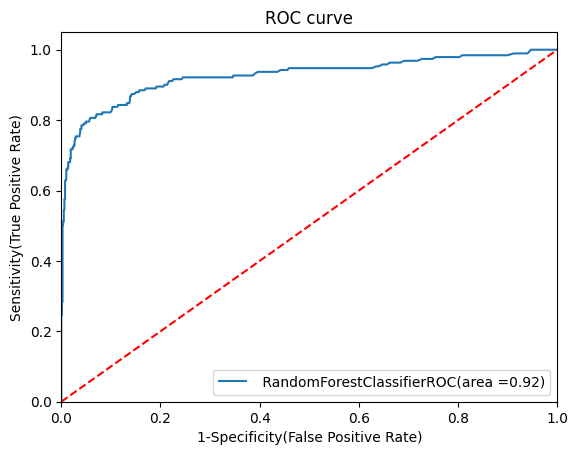

In [42]:
# plot ROC curve
from sklearn.metrics import roc_auc_score, roc_curve
plt.figure()  

auc_models=[
    {
        'label':'RandomForestClassifier',
        'model': RandomForestClassifier(n_estimators=1000, min_samples_split=2, max_features=7, max_depth=None),
        'auc':0.9151
    }
]

for algo in auc_models:
    model=algo['model']
    model.fit(x_train, y_train)
    fpr,tpr,thresholds=roc_curve(y_test, model.predict_proba(x_test)[:,1])
    plt.plot(fpr,tpr,label=' %sROC(area =%0.2f)' %(algo['label'], algo['auc']))
    plt.plot([0,1],[0,1],'r--')
    plt.xlim([0.0,1.0])
    plt.ylim([0.0,1.05])
    plt.xlabel('1-Specificity(False Positive Rate)')
    plt.ylabel('Sensitivity(True Positive Rate)')
    plt.title('ROC curve')
    plt.legend(loc='lower right')
    plt.savefig('auc.png')
    plt.show()